# Model predictive control (MPC)

This notebook runs discrete time online control loop

$$
\begin{aligned}
&x_0 \sim p(x_0)\\
&y_0 | x_0 \sim p(y_0 | x_0, t_0) \\
&\hat{x}_{0|0} = \text{FilterUpdate}(y_0, t_0) \\
&u_k, s_{k+1} = \text{ControlPolicy}(x_hat_{k|k}, s_k) \\
&x_{k+1} | x_k, u_k \sim p(x_{k+1} | x_k, u_k, t_k, t_{k+1}) \\
&y_{k+1} | x_{k+1}, u_k \sim p(y_{k+1} | x_{k+1}, u_k, t_{k+1}) \\
&\hat{x}_{k+1|k+1} = \text{FilterUpdate}(x_hat_{k|k}, u_k, y_{k+1}, t_k, t_{k+1}) \\
\end{aligned}
$$

with a control policy $\pi$ given by Model Predictive Path Integral (MPPI).


In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from dynestyx.control.discrete_controller_simulators import DiscreteControlLoopSimulator, filter_state_mean
from dynestyx.inference.configs.filter import KFConfig
from dynestyx.models import DynamicalModel
from dynestyx.models.observations import LinearGaussianObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution

## 1. Dynamics

We consider the same dynammics as in [controller demo](controller_demo.ipynb) where  $x_t \in \mathbb{R}^2$ obeys
$$
\begin{aligned}
dx_t &= A x_t^2 + u_t + \sigma\, dW_t \\
x_{t_k} &= x_{t_{k-1}} + \int_{t_{k-1}}^{t_k} Ax_s^2 + u_s ds + \sigma\int_{t_{k-1}}^{t_k}dW_s
\\
y_{t_k} &= H x_{t_k} + \eta_{t_k}
\end{aligned}
$$
with $A = \begin{pmatrix} 0.025 & 0.01 \\ 0.01 & 0.025 \end{pmatrix}$  and $H = \begin{pmatrix} 1 & 0
\end{pmatrix}$ (i.e. we only observe the first component). The discrete time dynamics are given by the continuous dynamics at discrete time $t_k = \Delta t k$. 

In [3]:
from dynestyx.inference.configs.filter import EnKFConfig, PFConfig
from dynestyx.models import ContinuousTimeStateEvolution, FullDiffusion

state_dim_2d = control_dim_2d = 2
obs_dim_2d = 1
A = jnp.array([[0.025, 0.01], [0.01, 0.025]])
sigma_2d = 0.1

continuous_nonlinear_dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(
        jnp.array([3.0, 2.0]), 0.05 * jnp.eye(state_dim_2d)
    ),
    state_evolution=ContinuousTimeStateEvolution(
        drift=lambda x, u, t: A @ (x**2) + u,
        diffusion=FullDiffusion(sigma_2d * jnp.eye(state_dim_2d)),
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim_2d, state_dim_2d), R=0.05 * jnp.eye(obs_dim_2d)
    ),
    control_dim=control_dim_2d,
)

from dynestyx.solvers import euler_maruyama_integrate_state_to_time

substep_dt = 0.02  # ~5 EM sub-steps per 0.1-spaced observation interval


class SubSteppedSDEStep:
    """A single control-loop transition that is itself a sub-stepped SDE
    integration -- the simulator only ever sees `.sample()`/`.shape()`,
    exactly as it would for e.g. a MuJoCo step."""

    def __init__(self, cte, x_prev, u, t_now, t_next, *, dt0):
        self._cte, self._x_prev, self._u = cte, x_prev, u
        self._t_now, self._t_next, self._dt0 = t_now, t_next, dt0

    def sample(self, key):
        x_out, _, _ = euler_maruyama_integrate_state_to_time(
            self._cte,
            self._x_prev,
            self._t_now,
            key,
            self._t_next,
            dt0=self._dt0,
            control_path_eval=lambda t: self._u,
        )
        return x_out

    def shape(self):
        return self._x_prev.shape


def black_box_sde_transition(x, u, t_now, t_next):
    return SubSteppedSDEStep(
        continuous_nonlinear_dynamics.state_evolution, x, u, t_now, t_next, dt0=substep_dt
    )


nonlinear_dynamics = DynamicalModel(
    initial_condition=continuous_nonlinear_dynamics.initial_condition,
    state_evolution=black_box_sde_transition,
    observation_model=continuous_nonlinear_dynamics.observation_model,
    control_dim=continuous_nonlinear_dynamics.control_dim,
)


## 2. A sampling-based MPC: Model Predictive Path Integral (MMPI)

Previously the policies so far have been deterministic linear feedback (`u = -K x_hat`). `dynestyx.control.MPPI` is a type of model predictive control: the dynamics model is used to optimize the chosen controls in an online manner: we solve an optimization problem for the control sequence $u_{k: k+N}$ over a horizon $N$ and execute the first control $u_{k}$, and repeat this process. This means that our policy $\pi$ will use the state transition $p(\cdot| x_k, u_k)$ (or some internal approximation).


Model Predictive Path Integral control is a sampling based approach to solving the optimization problem.  At every step, we sample many candidate control sequences, roll each one forward through the state transition, score them with a cost function, and take the softmax-weighted average as the actual control (only the first step of that average is applied; the rest becomes next step's warm-started plan). 

MPPI needs two things: a **rollout function** `(x0, u_seq) -> x_seq` for *planning* (this doesn't have to use `dynamics.state_evolution`; it could wrap an external simulator), and a **loss function** scoring a rolled-out trajectory. Here we build the rollout directly from `dynamics.state_evolution`'s mean: the real system is stochastic (see the control loop's own `.sample()` calls), but the *planner* only needs a reasonable prediction of where a candidate control sequence leads, not a faithful stochastic simulation.

In [ ]:
from dynestyx.control import MPPI
def make_mppi_rollout(dynamics, dt=1.0):
    def rollout_one(x0, u_seq):
        def step(x, u):
            x_next = dynamics.state_evolution(x, u, 0.0, dt).mean
            return x_next, x_next

        _, xs = jax.lax.scan(step, x0, u_seq)
        return xs

    return jax.vmap(rollout_one, in_axes=(None, 0))


def quadratic_loss(x_seq, u_seq):
    return jnp.sum(x_seq**2) + 0.01 * jnp.sum(u_seq**2)

`horizon` and `n_samples` trade off planning quality against compute; `noise_std` controls how widely candidate sequences are spread around the current plan, and `temperature` controls how sharply the softmax weighting favors low-cost samples. These values are not tuned beyond "converges reliably" -- the point here is the mechanism, not competitive performance. `dynamics`, `control_dim`, and `predict_times` are the same ones defined in section 1, and `trace_uncontrolled` (the `K=0` baseline) is reused directly from section 3 for comparison.

In [12]:
horizon = 10
n_samples = 300

mppi = MPPI(
    dynamics_model=make_mppi_rollout(dynamics),
    loss_fn=quadratic_loss,
    horizon=horizon,
    control_dim=control_dim,
    n_samples=n_samples,
    noise_std=1.0,
    temperature=1.0,
)

sim_mppi = DiscreteControlLoopSimulator(
    control_policy=mppi,
    filter_config=KFConfig(record_filtered_states_mean=True),
)

result_mppi = sim_mppi.simulate(dynamics, rng_key=jr.PRNGKey(0), predict_times=predict_times)

Same reading as before: observed (dots) and filtered (solid) state, contrasted against the `K=0` no-control baseline from section 3 (same dynamics, same key), plus MPPI's chosen control sequence.

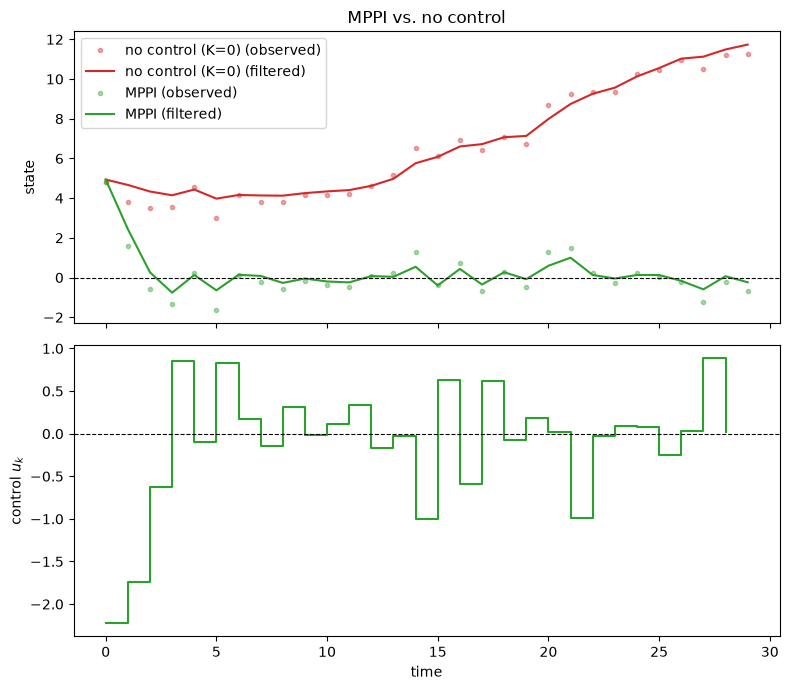

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs_mppi = [
    (result_uncontrolled, "no control (K=0)", "tab:red"),
    (result_mppi, "MPPI", "tab:green"),
]
for result, label, color in runs_mppi:
    t = result.times[0]
    obs = result.observations[0, :, 0]
    filtered_mean = result.filtered_states_mean[0, :, 0]
    axes[0].plot(t, obs, ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("MPPI vs. no control")

t_u = result_mppi.times[0][:-1]
u = result_mppi.controls[0, :, 0]
axes[1].step(t_u, u, where="post", color="tab:green")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()